## **Taller 8 - Random Forest - Árboles de Decisión y Clasificación**
Integrantes:
- Wilmer Santiago
- Bryan Montoya
- Andrew Quintero

## Instrucciones
Diseñe e implemente usando Python en un cuaderno de Jupyter algoritmos Random Forest que permitan clasificar dígitos escritos del dataset digits de SKlearn. Tenga en cuenta las siguientes consideraciones al desarrollar su solución:  



Divida el dataset en 80% para entrenamiento y 20% para prueba.  

Para el proceso de entrenamiento use K-fold = 4.  

  

Encuentre el mínimo número de árboles del menor tamaño posible que ofrezcan los mejores indicadores de rendimiento sin generar over-fitting.



Explique claramente la estrategia aplicada para podar o detener el crecimiento de los árboles. Revise el cuarderno de Jupyter en este enlace con información respecto al parámetro ccp_alpha.



## Imports

In [119]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay,f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Solution

In [2]:
SEED = 2000
digits = load_digits()
x = digits.data
y = digits.target
print(f'Forma de los datos: {x.shape}')
print(f'Forma de las etiquetas: {y.shape}')
print(f'Numero de clases {np.unique(y)}')
print(f'Distribución de las clases {np.bincount(y)}')

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Forma de los datos de entrenamiento: {x_train.shape}')
print(f'Forma de los datos de prueba: {x_test.shape}')
print(f'Numero de clases de los datos de prueba {np.unique(y_test)}')
print(f'Numero de clases de los datos de entrenamiento {np.unique(y_train)}')

Forma de los datos: (1797, 64)
Forma de las etiquetas: (1797,)
Numero de clases [0 1 2 3 4 5 6 7 8 9]
Distribución de las clases [178 182 177 183 181 182 181 179 174 180]
Forma de los datos de entrenamiento: (1437, 64)
Forma de los datos de prueba: (360, 64)
Numero de clases de los datos de prueba [0 1 2 3 4 5 6 7 8 9]
Numero de clases de los datos de entrenamiento [0 1 2 3 4 5 6 7 8 9]


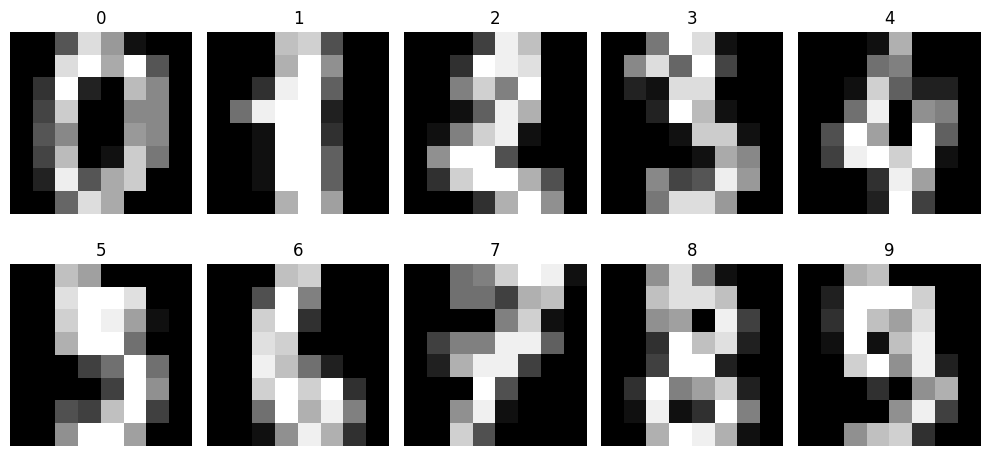

In [3]:
fig, axes = plt.subplots(2,5, figsize=(10,5))
for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
  ax.imshow(image, cmap="gray")
  ax.set_title(label)
  ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
arbol_base = DecisionTreeClassifier(random_state=SEED)
arbol_base.fit(x_train, y_train)
exactitud_arbol_base_train = arbol_base.score(x_train, y_train)
print(f'Exactitud del arbol base en entrenamiento: {exactitud_arbol_base_train:.4f}')
exactitud_arbol_base_test = arbol_base.score(x_test, y_test)
print(f'Exactitud del arbol base en prueba: {exactitud_arbol_base_test:.4f}')
print(f'Brecha del arbol entre el entrenamiento y la prueba: {(exactitud_arbol_base_train - exactitud_arbol_base_test):.4f}')
print(f'Profundidad del arbol: {arbol_base.get_depth()}')
print(f'Numero de hojas del arbol: {arbol_base.get_n_leaves()}')

Exactitud del arbol base en entrenamiento: 1.0000
Exactitud del arbol base en prueba: 0.8694
Brecha del arbol entre el entrenamiento y la prueba: 0.1306
Profundidad del arbol: 13
Numero de hojas del arbol: 141


In [28]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
resultado_cv= cross_validate(arbol_base, X =x_train, y=y_train, cv=cv, return_train_score=True, scoring='accuracy')
for i, (train_score, validation_score) in enumerate(zip(resultado_cv['train_score'], resultado_cv['test_score']), start=1):
  print(f'Partición {i}: Exactitud de entrenamiento: {train_score:.4f}, Validación: {validation_score:.4f}')

print(f'Exactitud promedio de entrenamiento: {np.mean(resultado_cv["train_score"]):.4f}')
print(f'Exactitud promedio de validación: {np.mean(resultado_cv["test_score"]):.4f}')
print(f'Desviación estandar: {resultado_cv['test_score'].std():.4f}')
print(f'Brecha promedio de exactitud: {np.mean(resultado_cv["train_score"]) - np.mean(resultado_cv["test_score"]):.4f}')

Partición 1: Exactitud de entrenamiento: 1.0000, Validación: 0.8306
Partición 2: Exactitud de entrenamiento: 1.0000, Validación: 0.8217
Partición 3: Exactitud de entrenamiento: 1.0000, Validación: 0.8384
Partición 4: Exactitud de entrenamiento: 1.0000, Validación: 0.8607
Exactitud promedio de entrenamiento: 1.0000
Exactitud promedio de validación: 0.8379
Desviación de las validaciones: 0.0145
Brecha de exactitud: 0.1621


Con estos resultados podemos ver que el arbol sufre de overfitting, ya que la brecha es considerablemente alta y al ver la exactitud del entrenamiento muestra perfección pero cae al compararlo con otros datos con los que no fueron entrenados. Aunque con la desviación estandar podemos ver que, a pesar del sobreajuste, el arbol es concistente en sus resultados aunque se cambien los datos de entrenamiento

Ahora pasaremos a podar el arbol:

In [36]:
ruta_poda = arbol_base.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = ruta_poda.ccp_alphas
print(f'Total de valores alpha: {len(ccp_alphas)}')
print(f'Primeros valores de alpha: {ccp_alphas[:5]}')
print(f'Ultimos valores de alpha: {ccp_alphas[-5:]}')
impurezas = ruta_poda.impurities

Total de valores alpha: 124
Primeros valores de alpha: [0.         0.00068771 0.00068933 0.00069589 0.00069589]
Ultimos valores de alpha: [0.04157336 0.0433014  0.05152418 0.0583448  0.06412186]


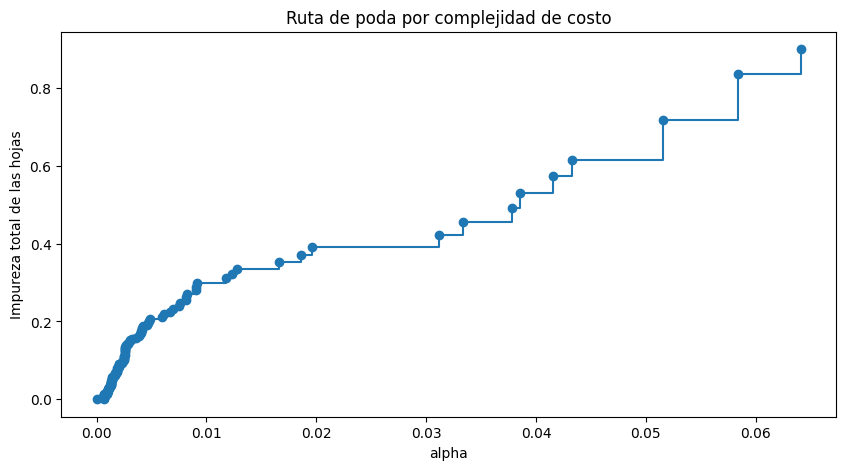

In [41]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ccp_alphas, impurezas, marker='o', drawstyle='steps-post')
ax.set_xlabel('alpha')
ax.set_ylabel('Impureza total de las hojas')
ax.set_title('Ruta de poda por complejidad de costo')
plt.show()

In [79]:
ccp_alphas_validos = np.unique(ccp_alphas[:-1])
promedio_train=[]
promedio_validation=[]
profundidades=[]
hojas =[]
brechas =[]
for alpha in ccp_alphas_validos:
  arbol_poda = DecisionTreeClassifier(random_state=SEED, ccp_alpha=alpha)
  resultado_poda = cross_validate(arbol_poda, X=x_train, y=y_train, cv=cv, return_train_score=True, scoring='accuracy')
  promedio_train.append(np.mean(resultado_poda['train_score']))
  promedio_validation.append(np.mean(resultado_poda['test_score']))
  brechas.append(np.mean(resultado_poda['train_score']) - np.mean(resultado_poda['test_score']))
  arbol_poda.fit(x_train, y_train)
  profundidades.append(arbol_poda.get_depth())
  hojas.append(arbol_poda.get_n_leaves())
mejor_indice = np.argmax(promedio_validation)
print(f'Mejor alpha: {ccp_alphas_validos[mejor_indice]:.4f}')
print(f'Exactitud promedio de entrenamiento: {promedio_train[mejor_indice]:.4f}')
print(f'Exactitud promedio de validación: {promedio_validation[mejor_indice]:.4f}')
print(f'Brecha promedio de exactitud: {promedio_train[mejor_indice] - promedio_validation[mejor_indice]:.4f}')
print(f'Profundidad del arbol: {profundidades[mejor_indice]}')
print(f'Numero de hojas del arbol: {hojas[mejor_indice]}')

Mejor alpha: 0.0018
Exactitud promedio de entrenamiento: 0.9566
Exactitud promedio de validación: 0.8379
Brecha promedio de exactitud: 0.1188
Profundidad del arbol: 12
Numero de hojas del arbol: 77


El anterior fue el indice con mejor validacion promedio, pero ahora vamos a buscar los que mejores validaciones en general tuvieron

In [80]:
orden_resultados = np.argsort(promedio_validation)[::-1]
for indice in orden_resultados[:10]:
    print(f'Alpha: {ccp_alphas_validos[indice]:.4f}')
    print(f'Exactitud promedio de entrenamiento: {promedio_train[indice]}')
    print(f'Exactitud promedio de validación: {promedio_validation[indice]}')
    print(f'Brecha promedio de exactitud: {brechas[indice]}')
    print(f'Profundidad del arbol: {profundidades[indice]}')
    print(f'Numero de hojas del arbol: {hojas[indice]}')
    print('-'*50)

Alpha: 0.0019
Exactitud promedio de entrenamiento: 0.9549989405739505
Exactitud promedio de validación: 0.8378655988857939
Brecha promedio de exactitud: 0.11713334168815659
Profundidad del arbol: 12
Numero de hojas del arbol: 76
--------------------------------------------------
Alpha: 0.0018
Exactitud promedio de entrenamiento: 0.956622532527825
Exactitud promedio de validación: 0.8378655988857939
Brecha promedio de exactitud: 0.1187569336420311
Profundidad del arbol: 12
Numero de hojas del arbol: 77
--------------------------------------------------
Alpha: 0.0007
Exactitud promedio de entrenamiento: 1.0
Exactitud promedio de validación: 0.8378617301145156
Brecha promedio de exactitud: 0.1621382698854844
Profundidad del arbol: 13
Numero de hojas del arbol: 137
--------------------------------------------------
Alpha: 0.0007
Exactitud promedio de entrenamiento: 1.0
Exactitud promedio de validación: 0.8378617301145156
Brecha promedio de exactitud: 0.1621382698854844
Profundidad del arbo

Dados estos indices con mejor validación haremos una busqueda entre todos con una tolerancia minima del 0.05% para encontrar aquel indice con una brecha pequeña entre su validación y su entrenamiento:

In [90]:
mejor_validation_global = max(promedio_validation)
tolerancia = 0.005

indices_aceptables = [indice for indice, validation in enumerate(promedio_validation) if validation + tolerancia >= mejor_validation_global]
indice_mas_simple = min(indices_aceptables, key=lambda indice: hojas[indice])
mejor_alpha= ccp_alphas_validos[indice_mas_simple]
print(f'Mejor alpha: {mejor_alpha:.4}')
print(f'Exactitud promedio de entrenamiento: {promedio_train[indice_mas_simple]:.4f}')
print(f'Exactitud promedio de validación: {promedio_validation[indice_mas_simple]:.4f}')
print(f'Brecha promedio de exactitud: {promedio_train[indice_mas_simple] - promedio_validation[indice_mas_simple]:.4f}')
print(f'Profundidad del arbol: {profundidades[indice_mas_simple]}')
print(f'Numero de hojas del arbol: {hojas[indice_mas_simple]}')

Mejor alpha: 0.002661
Exactitud promedio de entrenamiento: 0.9355
Exactitud promedio de validación: 0.8330
Brecha promedio de exactitud: 0.1025
Profundidad del arbol: 11
Numero de hojas del arbol: 48


Es así como tomaremos entonces este último alpha como la base para construir el Random Forest porque es el más simple (con 48) y el que guarda una buena relación entre su score de entrenamiento y su score al validar

In [92]:
bosque_base = RandomForestClassifier(n_estimators=100, ccp_alpha=mejor_alpha, random_state=SEED, n_jobs=-1)
resultado_bosque = cross_validate(bosque_base, X = x_train, y=y_train, cv=cv, return_train_score=True, scoring='accuracy')
promedio_train_bosque = resultado_bosque['train_score'].mean()
promedio_validation_bosque = resultado_bosque['test_score'].mean()
desviacion_bosque = resultado_bosque['test_score'].std()
brecha_bosque = promedio_train_bosque - promedio_validation_bosque
print(f'Exactitud promedio de entrenamiento: {promedio_train_bosque:.4f}')
print(f'Exactitud promedio de validación: {promedio_validation_bosque:.4f}')
print(f'Desviación estandar: {desviacion_bosque:.4f}')
print(f'Brecha promedio de exactitud: {brecha_bosque:.4f}')

Exactitud promedio de entrenamiento: 0.9998
Exactitud promedio de validación: 0.9701
Desviación estandar: 0.0087
Brecha promedio de exactitud: 0.0297


No están mal estos resultados porque la exactitud de validación es bastante buena y, aunque la exactitud entrenamiento también está alta, lo importante es la diferencia con la exactitud en validación también sea pequeña. Es decir, no suponemos un posible overfitting porque las exactitudes son altas y la brecha es baja.

Ahora vamos a variar el número de `n_estimators` para ver en qué punto el arbol deja de mejorar significativamente:

In [104]:
n_arboles = np.arange(100, 150)
'''
Llegamos a este rango tras probar del 1-250 y ver que las mejores exactitudes de validación
Estan entre 100 y 150
'''
promedios_train_rf =[]
promedios_validations_rf=[]
desviaciones_rf=[]
brechas_rf=[]
for n in n_arboles:
  bosque_n = RandomForestClassifier(n_estimators=n, ccp_alpha=mejor_alpha, random_state=SEED, n_jobs=-1)
  resultado_n = cross_validate(bosque_n, X = x_train, y=y_train, cv=cv, return_train_score=True, scoring='accuracy')
  promedios_train_rf.append(resultado_n['train_score'].mean())
  promedios_validations_rf.append(resultado_n['test_score'].mean())
  desviaciones_rf.append(resultado_n['test_score'].std())
  brechas_rf.append(resultado_n['train_score'].mean() - resultado_n['test_score'].mean())

Numero de arboles: 100
Exactitud promedio de entrenamiento: 0.9998
Exactitud promedio de validación: 0.9700731197771587
Desviación estandar: 0.0087
Brecha promedio de exactitud: 0.0297
--------------------------------------------------
Numero de arboles: 101
Exactitud promedio de entrenamiento: 0.9995
Exactitud promedio de validación: 0.9693786753327144
Desviación estandar: 0.0081
Brecha promedio de exactitud: 0.0302
--------------------------------------------------
Numero de arboles: 102
Exactitud promedio de entrenamiento: 0.9995
Exactitud promedio de validación: 0.9700750541627979
Desviación estandar: 0.0087
Brecha promedio de exactitud: 0.0295
--------------------------------------------------
Numero de arboles: 103
Exactitud promedio de entrenamiento: 0.9995
Exactitud promedio de validación: 0.9693786753327144
Desviación estandar: 0.0081
Brecha promedio de exactitud: 0.0302
--------------------------------------------------
Numero de arboles: 104
Exactitud promedio de entrenamien

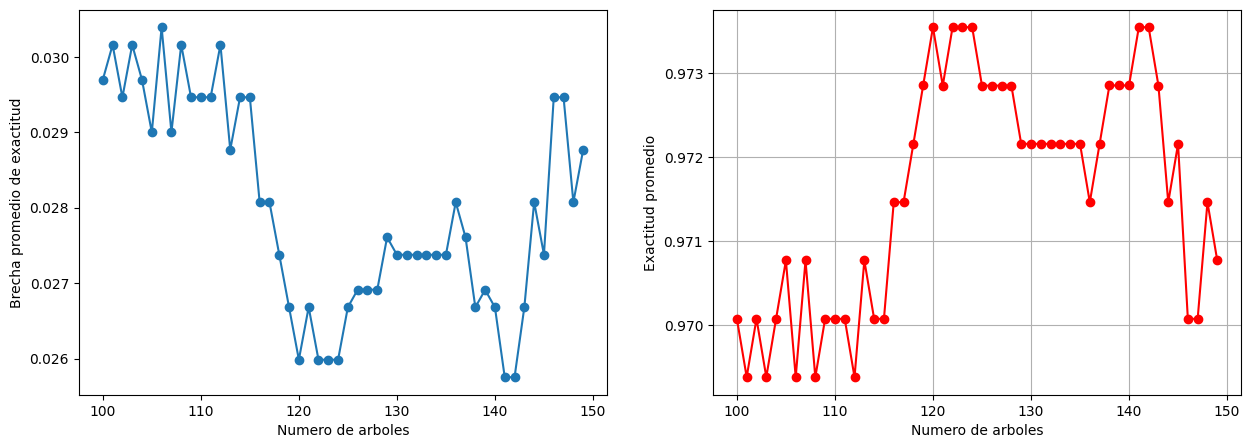

In [118]:
for i, n in enumerate(n_arboles):
  print(f'Numero de arboles: {n}')
  print(f'Exactitud promedio de entrenamiento: {promedios_train_rf[i]:.4f}')
  print(f'Exactitud promedio de validación: {promedios_validations_rf[i]}')
  print(f'Desviación estandar: {desviaciones_rf[i]:.4f}')
  print(f'Brecha promedio de exactitud: {brechas_rf[i]:.4f}')
  print('-'*50)

fig,ax= plt.subplots(1,2,figsize=(15,5))
ax[0].plot(n_arboles, brechas_rf, marker='o')
ax[1].plot(n_arboles, promedios_validations_rf, marker='o', color='red')
ax[0].set_xlabel('Numero de arboles')
ax[0].set_ylabel('Brecha promedio de exactitud')
ax[1].set_xlabel('Numero de arboles')
ax[1].set_ylabel('Exactitud promedio')
plt.grid()
plt.show()

A pesar de que hay varios números de arboles que tienen la misma brecha, en este caso escogeré aquella que necesita menos número de arboles para la misma brecha que serían 120 arboles.

> Nota: Viendo los resultados nos daremos cuenta que entre 123 le gana en exactitud de validación a 120, pero con una maginitud $10^{-14}$ que consideraremos un valor despreciable para nuestro análisis al ser muy cercano a 0

Entonces, ya tenemos nuestros hiperparámetros:
- n° de arboles = 120
- ccp_alpha = 0.002661

Exactitud del arbol final en entrenamiento: 0.9965
Exactitud del arbol final en prueba: 0.9722
Brecha del arbol entre el entrenamiento y la prueba: 0.0243
Exactitud balanceada: 0.9721
F1 macro: 0.9721


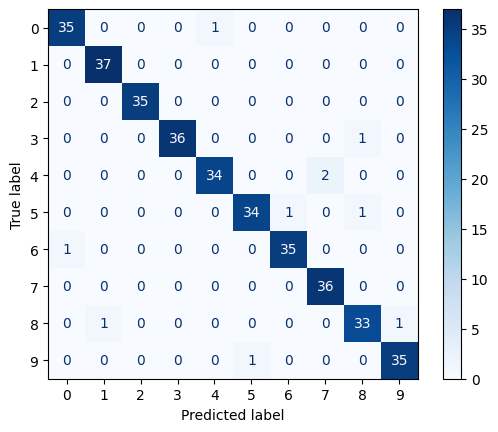

In [122]:
modelo_final = RandomForestClassifier(n_estimators=120, ccp_alpha=mejor_alpha, random_state=SEED, n_jobs=-1)
modelo_final.fit(x_train, y_train)
y_pred = modelo_final.predict(x_test)
exactitud_train_final = modelo_final.score(x_train, y_train)
exactitud_test_final = accuracy_score(y_test, y_pred)
exactitud_balanceada = balanced_accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
brecha_final = exactitud_train_final - exactitud_test_final
print(f'Exactitud del arbol final en entrenamiento: {exactitud_train_final:.4f}')
print(f'Exactitud del arbol final en prueba: {exactitud_test_final:.4f}')
print(f'Brecha del arbol entre el entrenamiento y la prueba: {brecha_final:.4f}')
print(f'Exactitud balanceada: {exactitud_balanceada:.4f}')
print(f'F1 macro: {f1_macro:.4f}')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()

El Random Forest con 120 arboles y `ccp_alpha = 0.002661` obtuvo una exactitud de prueba del 97,22% y una exactitud balanceada del 97,21%. Además, un F1 macro de 97,21% también. Sumado al hecho que la brecha tampoco es muy alta, de apenas el 2,43% entre los datos de entrenamiento y los de prueba, no indicando un overfitting que pueda ser considerado.

Teniendo en cuenta los datos con la validación cruzada, estos disminuyeron un poco su exactitud en la validación real (en un 0.14%) pero con una cifra tan baja que es tolerable porque es esperable debido a la diversidad de los números